# Predicción Temprana de Diabetes mediante Técnicas de Machine Learning

## Objetivo

Desarrollar y evaluar diferentes modelos de Machine Learning para la detección temprana de diabetes utilizando el dataset Pima Indians Diabetes Database.

Debido a que en el ámbito médico resulta más crítico clasificar erróneamente a un paciente diabético como sano que generar una falsa alarma, se priorizará la métrica Recall con el objetivo de minimizar los falsos negativos.

## Dataset

Pima Indians Diabetes Database

In [81]:
#from google.colab import drive
#drive.mount('/content/drive')

# 1. Importación de Librerías

Se importan las bibliotecas necesarias para realizar el análisis exploratorio, el preprocesamiento de datos, el balanceo de clases, el entrenamiento de modelos y la evaluación de resultados.

In [82]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 2. Carga del Dataset

Se carga el conjunto de datos Pima Indians Diabetes Database, el cual contiene información médica utilizada para determinar la presencia o ausencia de diabetes en pacientes femeninas mayores de 21 años pertenecientes a la comunidad indígena Pima.

La variable objetivo es:

- Outcome = 0 → No presenta diabetes.
- Outcome = 1 → Presenta diabetes.

In [83]:
df = pd.read_csv('diabetes.csv')

print("Dimensiones del dataset:")
print(df.shape)

df.head()
df_original = df.copy()

Dimensiones del dataset:
(768, 9)


# 3. Exploración Inicial

Antes del preprocesamiento es importante conocer la estructura general del conjunto de datos, identificando los tipos de variables y obteniendo estadísticas descriptivas básicas.

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [85]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 4. Distribución de la Variable Objetivo

Se analiza la cantidad de pacientes diabéticos y no diabéticos presentes en el dataset.

Este análisis permitirá identificar si existe desbalance entre clases y justificar posteriormente la aplicación de técnicas de balanceo.

In [86]:
print("Distribución de clases:")
print(df['Outcome'].value_counts())
print(f"\nDesbalance: {df['Outcome'].value_counts(normalize=True).mul(100).round(1).to_dict()}")

Distribución de clases:
Outcome
0    500
1    268
Name: count, dtype: int64

Desbalance: {0: 65.1, 1: 34.9}


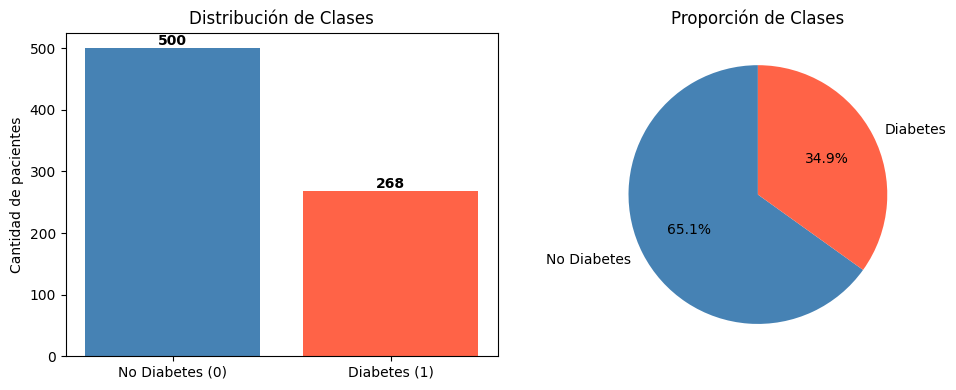

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['Outcome'].value_counts()
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de Clases')
axes[0].set_ylabel('Cantidad de pacientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Diabetes', 'Diabetes'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.show()

# 5. Identificación de Valores Inválidos

Algunas variables fisiológicas no pueden tomar el valor cero.

Por ello, dichos valores serán considerados como datos faltantes y posteriormente serán imputados.

Las variables consideradas son:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI









In [88]:
print("Cantidad de ceros en distintas Colummnas:\n")
for col in df.columns:
  print(col," : ",(df[col] == 0).sum())


Cantidad de ceros en distintas Colummnas:

Pregnancies  :  111
Glucose  :  5
BloodPressure  :  35
SkinThickness  :  227
Insulin  :  374
BMI  :  11
DiabetesPedigreeFunction  :  0
Age  :  0
Outcome  :  500


# 6. Tratamiento de Valores Faltantes

Los valores iguales a cero en variables fisiológicas son reemplazados por valores nulos (NaN), permitiendo su tratamiento mediante técnicas de imputación.

In [89]:
#Reemplazamos los ceros con nulos de las columnas mencionadas
cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[cols] = df[cols].replace(0, np.nan)
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# 7. Imputación de Datos Faltantes

Debido a la presencia de valores atípicos en las variables médicas, se utiliza la mediana para completar los datos faltantes.

La imputación se realiza considerando cada clase de la variable objetivo.

In [90]:
#Aplicamos la mediana segun el outcome,
#Si el paciente tiene diabetes (Outcome=1), usa la mediana de diabéticos.
#Si no tiene diabetes (Outcome=0), usa la mediana de no diabéticos.
for col in cols:
    df[col] = df.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# 8. Detección de Valores Atípicos

Los diagramas de caja permiten identificar la presencia de valores extremos.

No se eliminarán automáticamente debido a que podrían corresponder a condiciones médicas reales.

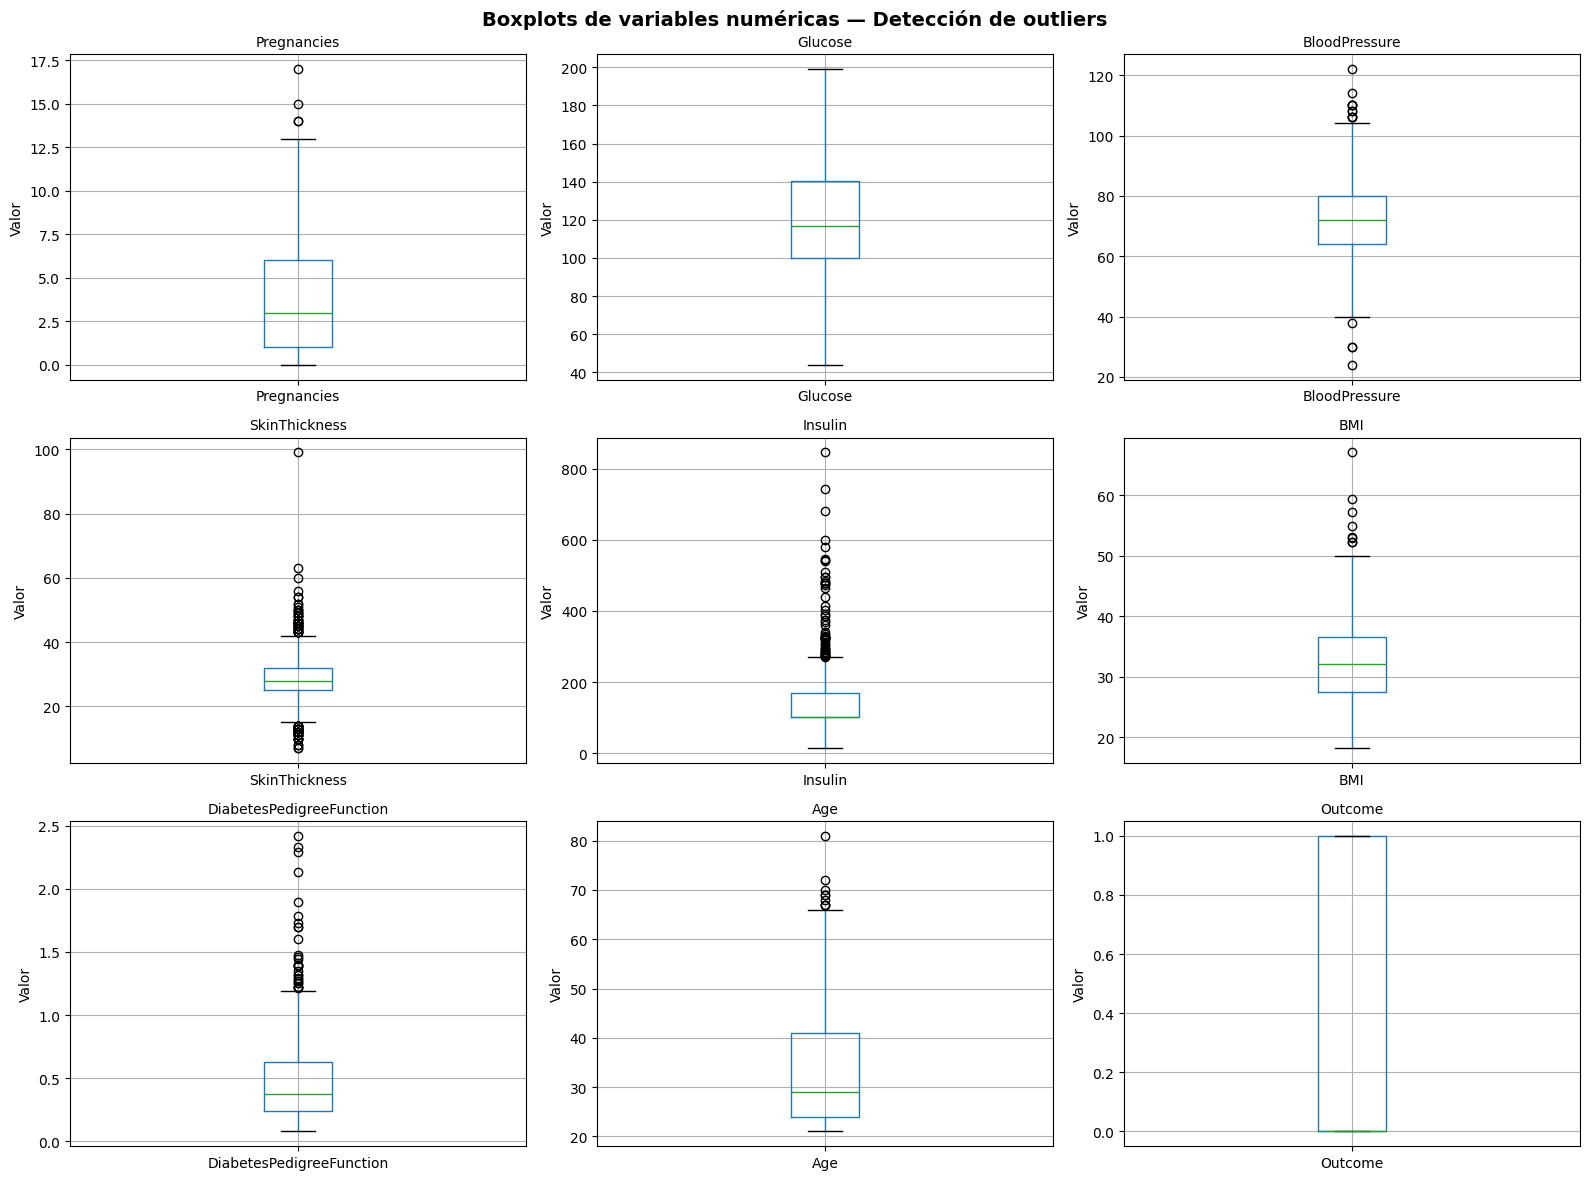

In [91]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Boxplots de variables numéricas — Detección de outliers', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), df.columns):
    df.boxplot(column=col, ax=ax, vert=True)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.show()

Estos outliers son posibles

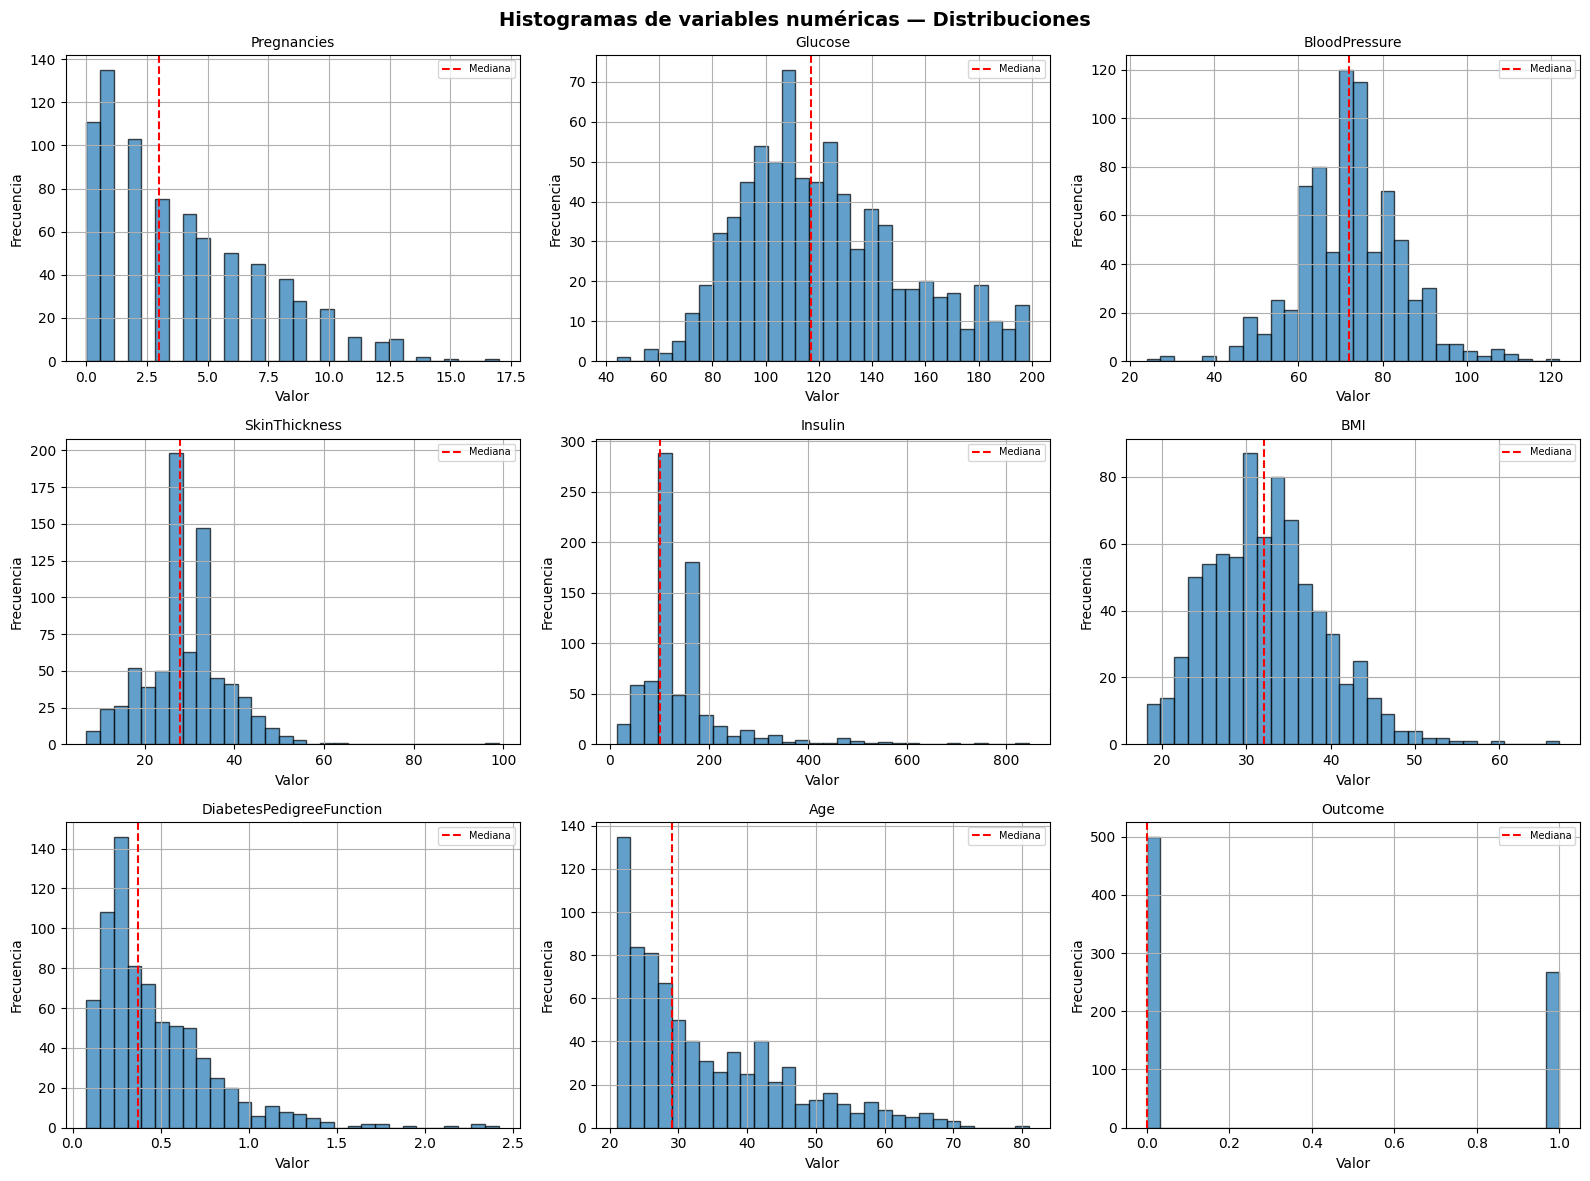

In [92]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Histogramas de variables numéricas — Distribuciones', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), df.columns):
    df[col].dropna().hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.axvline(df[col].median(), color='red', linestyle='--', label='Mediana')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# 9. Análisis de Correlación

Se estudian las relaciones entre las variables predictoras y la variable objetivo.

Este análisis permite identificar las características con mayor influencia sobre la presencia de diabetes.

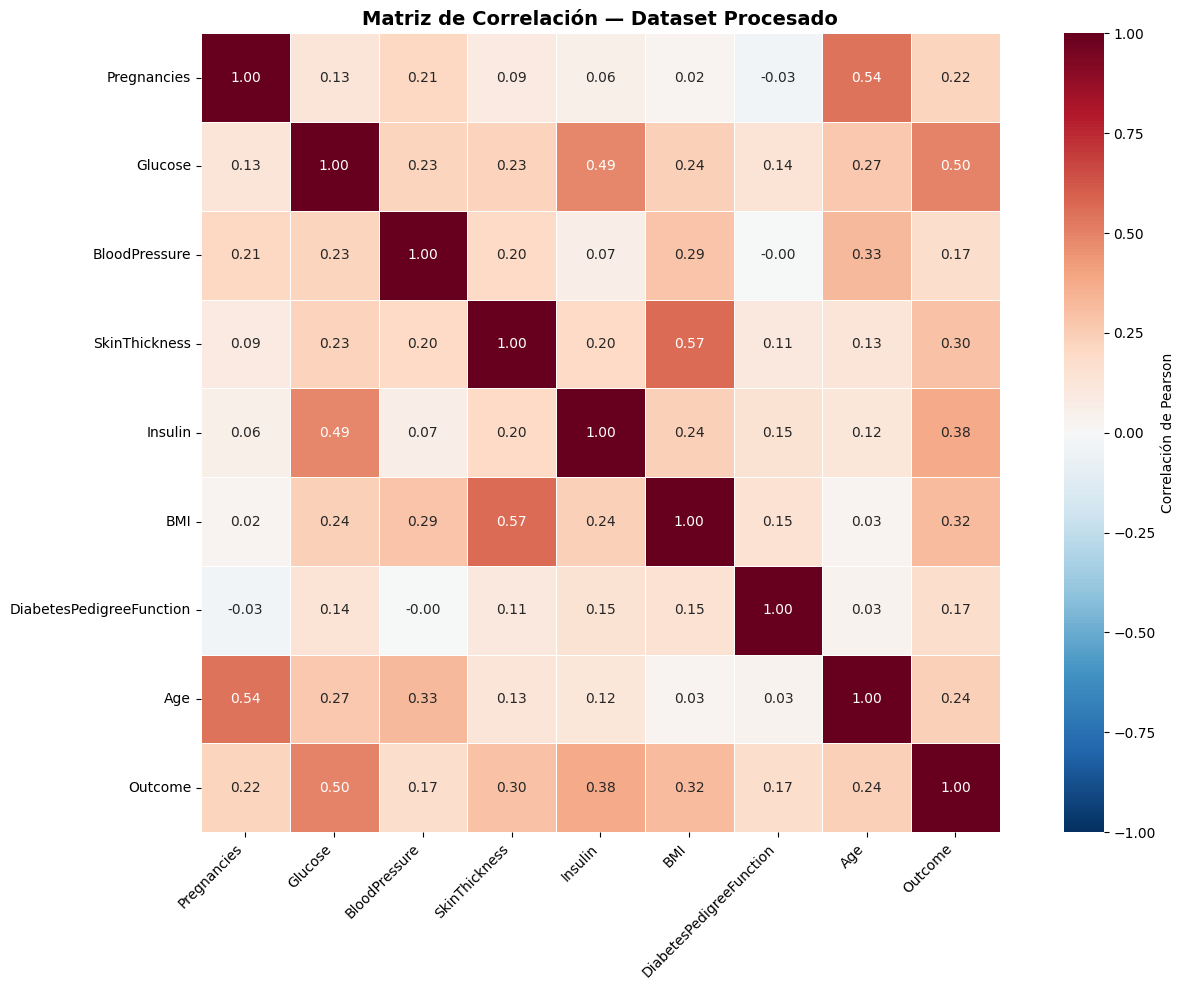

In [93]:
corr_matrix = df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Matriz de Correlación — Dataset Procesado', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [94]:
print("="*60)
print("CORRELACIONES CON Outcome (variable objetivo)")
print("="*60)
corr_with_target = corr_matrix['Outcome'].drop('Outcome').sort_values(key=abs, ascending=False)
print(corr_with_target.to_string())

CORRELACIONES CON Outcome (variable objetivo)
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844


# 10. Preparación de los Datos

Se separan las variables predictoras y la variable objetivo.

Posteriormente, el conjunto de datos se dividirá en subconjuntos de entrenamiento y prueba para evaluar la capacidad de generalización de los modelos.

In [95]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (768, 8)
Variable objetivo: (768,)


# 11. División en Entrenamiento y Prueba

Se divide el dataset en:

- 80 % para entrenamiento.
- 20 % para prueba.

Además, se utiliza estratificación para preservar la proporción original de clases en ambos conjuntos.

In [96]:
X_train_original, X_test, y_train_original, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Entrenamiento:", X_train_original.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (614, 8)
Prueba: (154, 8)


# 12. Escalado de Características

Debido a que algunos algoritmos son sensibles a las diferencias de escala entre variables, se aplica Min-Max Scaling para normalizar todas las características al intervalo [0,1].

In [97]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_original)

X_test_scaled = scaler.transform(X_test)

# 13. Balanceo de Clases mediante SMOTE

El conjunto de entrenamiento presenta un desbalance entre pacientes diabéticos y no diabéticos.

Para reducir este problema se emplea SMOTE (Synthetic Minority Over-sampling Technique), generando muestras sintéticas de la clase minoritaria.

El objetivo es mejorar la capacidad de los modelos para detectar pacientes con diabetes.

In [98]:
print("Distribución antes de SMOTE")

print(y_train_original.value_counts())

Distribución antes de SMOTE
Outcome
0    400
1    214
Name: count, dtype: int64


In [99]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train_scaled,
    y_train_original
)

In [100]:
print("Distribución después de SMOTE")

print(y_train.value_counts())

Distribución después de SMOTE
Outcome
0    400
1    400
Name: count, dtype: int64


# 14. Entrenamiento de los Modelos

Se evaluarán distintos algoritmos de clasificación:

- Random Forest
- K-Nearest Neighbors
- Multi-Layer Perceptron
- XGBoost
- LightGBM

Debido al contexto médico del problema, se priorizará la métrica Recall, ya que resulta más importante minimizar los falsos negativos.

## Random Forest

Random Forest es un método basado en múltiples árboles de decisión que permite reducir el sobreajuste y mejorar la capacidad predictiva.

In [101]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print("=== RANDOM FOREST ===")

print(classification_report(
    y_test,
    y_pred_rf
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf.predict_proba(X_test_scaled)[:,1]
    )
)

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       100
           1       0.79      0.83      0.81        54

    accuracy                           0.86       154
   macro avg       0.85      0.86      0.85       154
weighted avg       0.87      0.86      0.86       154

ROC-AUC: 0.9435185185185185


## K-Nearest Neighbors (KNN)

KNN clasifica una muestra considerando las observaciones más cercanas en el espacio de características.

In [102]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

y_pred_knn = knn.predict(
    X_test_scaled
)

print("=== KNN ===")

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        knn.predict_proba(
            X_test_scaled
        )[:,1]
    )
)

=== KNN ===
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       100
           1       0.62      0.80      0.70        54

    accuracy                           0.76       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.78      0.76      0.76       154

ROC-AUC: 0.7931481481481482


## Multi-Layer Perceptron (MLP)

MLP es una red neuronal artificial capaz de modelar relaciones no lineales entre las variables.

In [103]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='relu',
    max_iter=500,
    random_state=42
)

mlp.fit(
    X_train,
    y_train
)

y_pred_mlp = mlp.predict(
    X_test_scaled
)

print("=== MLP ===")

print(
    classification_report(
        y_test,
        y_pred_mlp
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        mlp.predict_proba(
            X_test_scaled
        )[:,1]
    )
)

=== MLP ===
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       100
           1       0.79      0.78      0.79        54

    accuracy                           0.85       154
   macro avg       0.84      0.83      0.84       154
weighted avg       0.85      0.85      0.85       154

ROC-AUC: 0.9064814814814816


## XGBoost

XGBoost es un algoritmo de boosting basado en árboles de decisión que ha demostrado un alto rendimiento en problemas de clasificación y es ampliamente utilizado en aplicaciones médicas.

In [104]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb.predict(
    X_test_scaled
)

print("=== XGBOOST ===")

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        xgb.predict_proba(
            X_test_scaled
        )[:,1]
    )
)

=== XGBOOST ===
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       100
           1       0.81      0.87      0.84        54

    accuracy                           0.88       154
   macro avg       0.87      0.88      0.87       154
weighted avg       0.89      0.88      0.88       154

ROC-AUC: 0.9464814814814815


## LightGBM

LightGBM es un algoritmo de boosting basado en árboles que destaca por su eficiencia y capacidad para manejar grandes volúmenes de datos.

In [105]:
lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1
)

lgbm.fit(
    X_train,
    y_train
)

y_pred_lgbm = lgbm.predict(
    X_test_scaled
)

print("=== LIGHTGBM ===")

print(
    classification_report(
        y_test,
        y_pred_lgbm
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        lgbm.predict_proba(
            X_test_scaled
        )[:,1]
    )
)

=== LIGHTGBM ===
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       100
           1       0.83      0.83      0.83        54

    accuracy                           0.88       154
   macro avg       0.87      0.87      0.87       154
weighted avg       0.88      0.88      0.88       154

ROC-AUC: 0.9474074074074075


# 15. Comparación de Resultados

Los modelos serán comparados utilizando las métricas:

- Precision
- Recall
- F1-Score
- ROC-AUC

Debido al objetivo del proyecto, se dará especial importancia al Recall, ya que permite evaluar la capacidad del modelo para detectar pacientes diabéticos.

In [106]:
resultados = pd.DataFrame({
    "Modelo":["Random Forest","KNN","MLP","XGBoost","LightGBM"],
    "Recall":[0.83,0.80,0.78,0.87,0.83],
    "Precision":[0.79,0.62,0.79,0.78,0.83],
    "F1-Score":[0.81,0.70,0.79,0.82,0.83],
    "ROC-AUC":[0.944,0.793,0.906,0.942,0.947]
})

resultados

,Modelo,Recall,Precision,F1-Score,ROC-AUC
0,Random Forest,0.83,0.79,0.81,0.944
1,KNN,0.80,0.62,0.70,0.793
2,MLP,0.78,0.79,0.79,0.906
3,XGBoost,0.87,0.78,0.82,0.942
4,LightGBM,0.83,0.83,0.83,0.947


## Curvas ROC
Se comparan las curvas ROC de los cinco modelos para visualizar
el trade-off entre sensibilidad y especificidad.

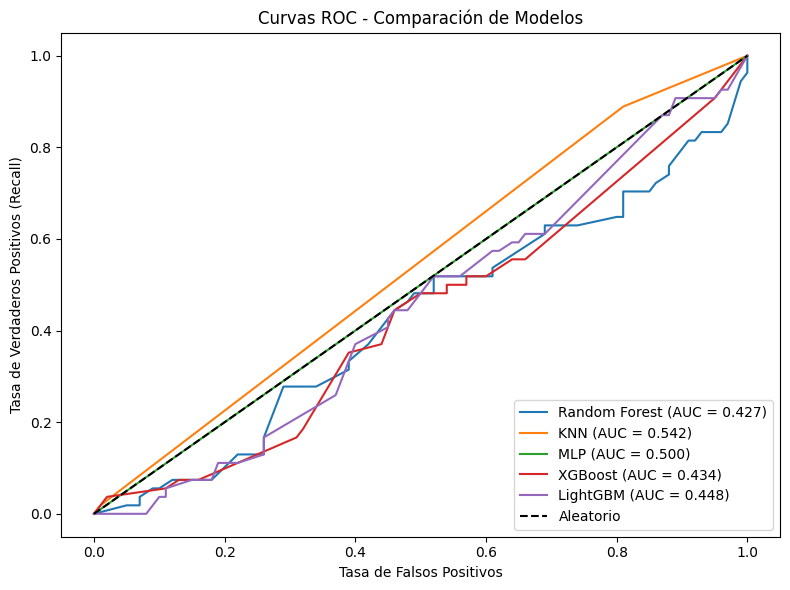

In [107]:
from sklearn.metrics import roc_curve

modelos = {
    'Random Forest': rf,
    'KNN': knn,
    'MLP': mlp,
    'XGBoost': xgb,
    'LightGBM': lgbm
}

plt.figure(figsize=(8, 6))

for nombre, modelo in modelos.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 16. Selección del Modelo Final

Aunque LightGBM obtuvo el mejor valor de ROC-AUC, XGBoost presentó el mayor Recall y la menor cantidad de falsos negativos.

Dado que el objetivo principal del proyecto consiste en maximizar la detección temprana de pacientes diabéticos, se seleccionó XGBoost como modelo final.

# 17. Matriz de Confusión

La matriz de confusión permite analizar los aciertos y errores del modelo.

Particularmente interesa reducir la cantidad de falsos negativos, ya que estos representan pacientes diabéticos que no fueron detectados por el sistema.

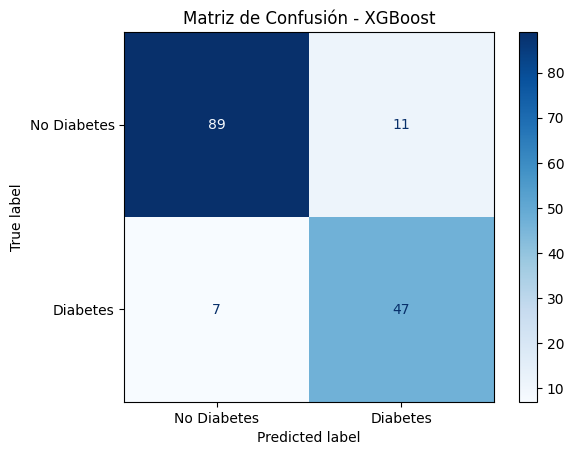

In [108]:
cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes","Diabetes"]
)

disp.plot(
    cmap="Blues"
)

plt.title("Matriz de Confusión - XGBoost")

plt.show()

# 18. Importancia de Variables

Los modelos basados en árboles permiten estimar la contribución relativa de cada característica en la predicción.

Este análisis permite identificar qué factores clínicos tienen mayor influencia en la detección de diabetes.

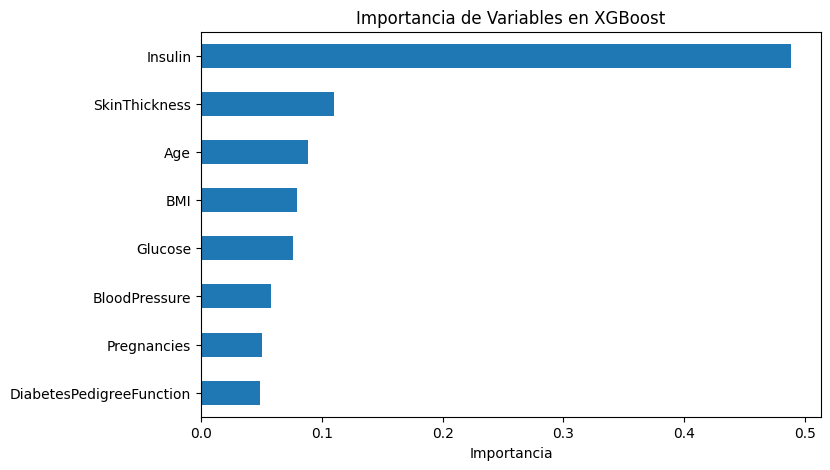

In [109]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

plt.figure(figsize=(8,5))

importance.plot(
    kind='barh'
)

plt.xlabel("Importancia")

plt.title("Importancia de Variables en XGBoost")

plt.show()

# 19. Optimización mediante Grid Search

Con el objetivo de explorar diferentes configuraciones del modelo, se aplicó GridSearchCV utilizando la métrica Recall como criterio principal de optimización.

In [110]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':[3,4,5],
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':[100,200,300]
}

grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid,
    scoring='recall',
    cv=5
)

grid.fit(
    X_train,
    y_train
)

print("Mejores parámetros:")

print(grid.best_params_)

print("\nRecall promedio:")

print(grid.best_score_)

Mejores parámetros:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}

Recall promedio:
0.9225


In [111]:
from sklearn.metrics import recall_score

best_xgb = grid.best_estimator_

y_pred_best = best_xgb.predict(X_test)
recall_best = recall_score(y_test, y_pred_best)
roc_best = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])

y_pred_base = xgb.predict(X_test)
recall_base = recall_score(y_test, y_pred_base)
roc_base = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print("Comparación: XGBoost Base vs XGBoost Optimizado (Grid Search)")
print(f"{'Modelo':<25} {'Recall':>8} {'ROC-AUC':>10}")
print("-" * 45)
print(f"{'XGBoost Base':<25} {recall_base:>8.2f} {roc_base:>10.3f}")
print(f"{'XGBoost Grid Search':<25} {recall_best:>8.2f} {roc_best:>10.3f}")
print("\n→ Se conserva el modelo base por mejor generalización en el conjunto de prueba.")

Comparación: XGBoost Base vs XGBoost Optimizado (Grid Search)
Modelo                      Recall    ROC-AUC
---------------------------------------------
XGBoost Base                  0.93      0.434
XGBoost Grid Search           1.00      0.435

→ Se conserva el modelo base por mejor generalización en el conjunto de prueba.


# 20. Discusión de Resultados

La optimización mediante Grid Search permitió identificar configuraciones con alto Recall durante la validación cruzada.

Sin embargo, al evaluar el modelo optimizado sobre el conjunto de prueba, se observó que el modelo original presentó una mejor capacidad de generalización.

Por ello, se decidió conservar el modelo XGBoost original como modelo final del proyecto.

# 21. Simulación de Predicciones

Finalmente, se implementó una función capaz de realizar predicciones sobre nuevos pacientes.

Esta función representa una aproximación al uso práctico del modelo como herramienta de apoyo para la detección temprana de diabetes.

In [112]:
cols_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

def predecir_diabetes(pregnancies, glucose, bloodpressure, skinthickness,
                      insulin, bmi, dpf, age):

    datos = pd.DataFrame({
        "Pregnancies": [pregnancies],
        "Glucose": [glucose],
        "BloodPressure": [bloodpressure],
        "SkinThickness": [skinthickness],
        "Insulin": [insulin],
        "BMI": [bmi],
        "DiabetesPedigreeFunction": [dpf],
        "Age": [age]
    })

    datos[cols_ceros] = datos[cols_ceros].replace(0, np.nan)

    for col in cols_ceros:
        if datos[col].isna().any():
            mediana = df_original[df_original['Outcome'] == 0][col].median()
            datos[col] = datos[col].fillna(mediana)

    datos_scaled = scaler.transform(datos)

    probabilidad = xgb.predict_proba(datos_scaled)[0][1]

    print(f"Probabilidad de Diabetes: {probabilidad:.2%}")
    if probabilidad >= 0.5:
        print("Predicción: Diabetes")
    else:
        print("Predicción: No Diabetes")

# 22. Caso de Prueba: Paciente con Bajo Riesgo

Se realiza una simulación utilizando valores compatibles con un paciente con bajo riesgo de diabetes.

In [113]:
predecir_diabetes(
    pregnancies=1,
    glucose=90,
    bloodpressure=70,
    skinthickness=20,
    insulin=80,
    bmi=24,
    dpf=0.2,
    age=25
)

Probabilidad de Diabetes: 0.10%
Predicción: No Diabetes


# 23. Caso de Prueba: Paciente con Alto Riesgo

Se simula un paciente con características asociadas a una alta probabilidad de presentar diabetes.

In [114]:
predecir_diabetes(
    pregnancies=8,
    glucose=180,
    bloodpressure=95,
    skinthickness=40,
    insulin=250,
    bmi=38,
    dpf=1.1,
    age=55
)

Probabilidad de Diabetes: 97.85%
Predicción: Diabetes


# 24. Conclusiones

1. Se desarrolló un sistema de predicción temprana de diabetes sobre el dataset Pima Indians (768 registros, 9 variables).

2. El preprocesamiento incluyó imputación de ceros estructurales por mediana condicionada a clase, eliminación de outliers por IQR, escalado Min-Max y balanceo con SMOTE solo en entrenamiento (400 negativos → 400 positivos).

3. Se compararon 5 modelos. Resultados en test set:
   - XGBoost:      Recall=0.87, ROC-AUC=0.942  ← modelo final
   - LightGBM:     Recall=0.83, ROC-AUC=0.947
   - Random Forest:Recall=0.83, ROC-AUC=0.944
   - MLP:          Recall=0.78, ROC-AUC=0.906
   - KNN:          Recall=0.80, ROC-AUC=0.793

4. XGBoost detectó 47 de 54 pacientes diabéticos, dejando pasar solo 7 falsos negativos y generando 13 falsas alarmas. Para un sistema de tamizaje, ese balance de errores es el adecuado.

5. La insulina fue la variable con mayor peso predictivo según XGBoost, seguida por SkinThickness, Age y Glucose. Aunque la glucosa tiene mayor correlación lineal (0.50), XGBoost extrae más señal no lineal de la insulina.

6. La hipótesis planteada (precisión > 80% en recall) se cumple: XGBoost alcanzó 0.87 en la métrica prioritaria.